# Australia fires:

## 1) Analyze correlations between IOD/ENSO/SAM and Australia rains

In [1]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy import linalg
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pickle
import copy

#%matplotlib widget

# Import the csv datasets:
# -----------------------
dir='../../../Data-for-teaching-staff/Heat-waves/Siberian-heat-waves/'
file='Verhojansk.csv'
dataset = pd.read_csv(dir+file,delim_whitespace=False,na_values='NaN' \
    ,comment='#',skipinitialspace=True,skip_blank_lines=True,header=0)
data = np.asarray(dataset.iloc[:, :].values)
header= dataset.iloc[:, :].columns
Tmax=np.asarray(data[:,8],dtype='float')
Tmax_date_strings=data[:,5]
Tmax_dates=np.asarray([datetime.strptime(string, '%Y-%m-%d') \
                       for string in Tmax_date_strings])
Tmax_year=np.asarray([date.year for date in Tmax_dates])

# use only data starting 1925, too many missing data before:
Tmax=Tmax[Tmax_year>1924]
Tmax_dates=Tmax_dates[Tmax_year>1924]

# eliminate missing data points for Tmax:
Tmax_dates=Tmax_dates[np.logical_not(np.isnan(Tmax))]
Tmax=Tmax[np.logical_not(np.isnan(Tmax))]

# eliminate extra day for leap years:
Tmax_day_of_year=np.asarray([date.timetuple().tm_yday for date in Tmax_dates])
Tmax_dates=Tmax_dates[np.logical_not(Tmax_day_of_year==366)]
Tmax=Tmax[np.logical_not(Tmax_day_of_year==366)]

# recalculate year number and day of year for selected data points only:
Tmax_year=np.asarray([date.year for date in Tmax_dates])
Tmax_day_of_year=np.asarray([date.timetuple().tm_yday for date in Tmax_dates])


print("done loading libraries and data.")

done loading libraries and data.


/var/folders/0v/wvw14yq11b34jdy4j2h8fsx80000gn/T/ipykernel_8907/3314834134.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataset = pd.read_csv(dir+file,delim_whitespace=False,na_values='NaN' \


In [2]:
# save data to be pickled for students, use same number of 
# years for all records to make things easier for them:

np.save("Output/to-pickle/Verhojansk_Tmax.npy", Tmax)
np.save("Output/to-pickle/Verhojansk_Tmax_dates.npy", Tmax_dates)
np.save("Output/to-pickle/Verhojansk_Tmax_day_of_year.npy", Tmax_day_of_year)

print("done saving time series to be pickled.")

done saving time series to be pickled.


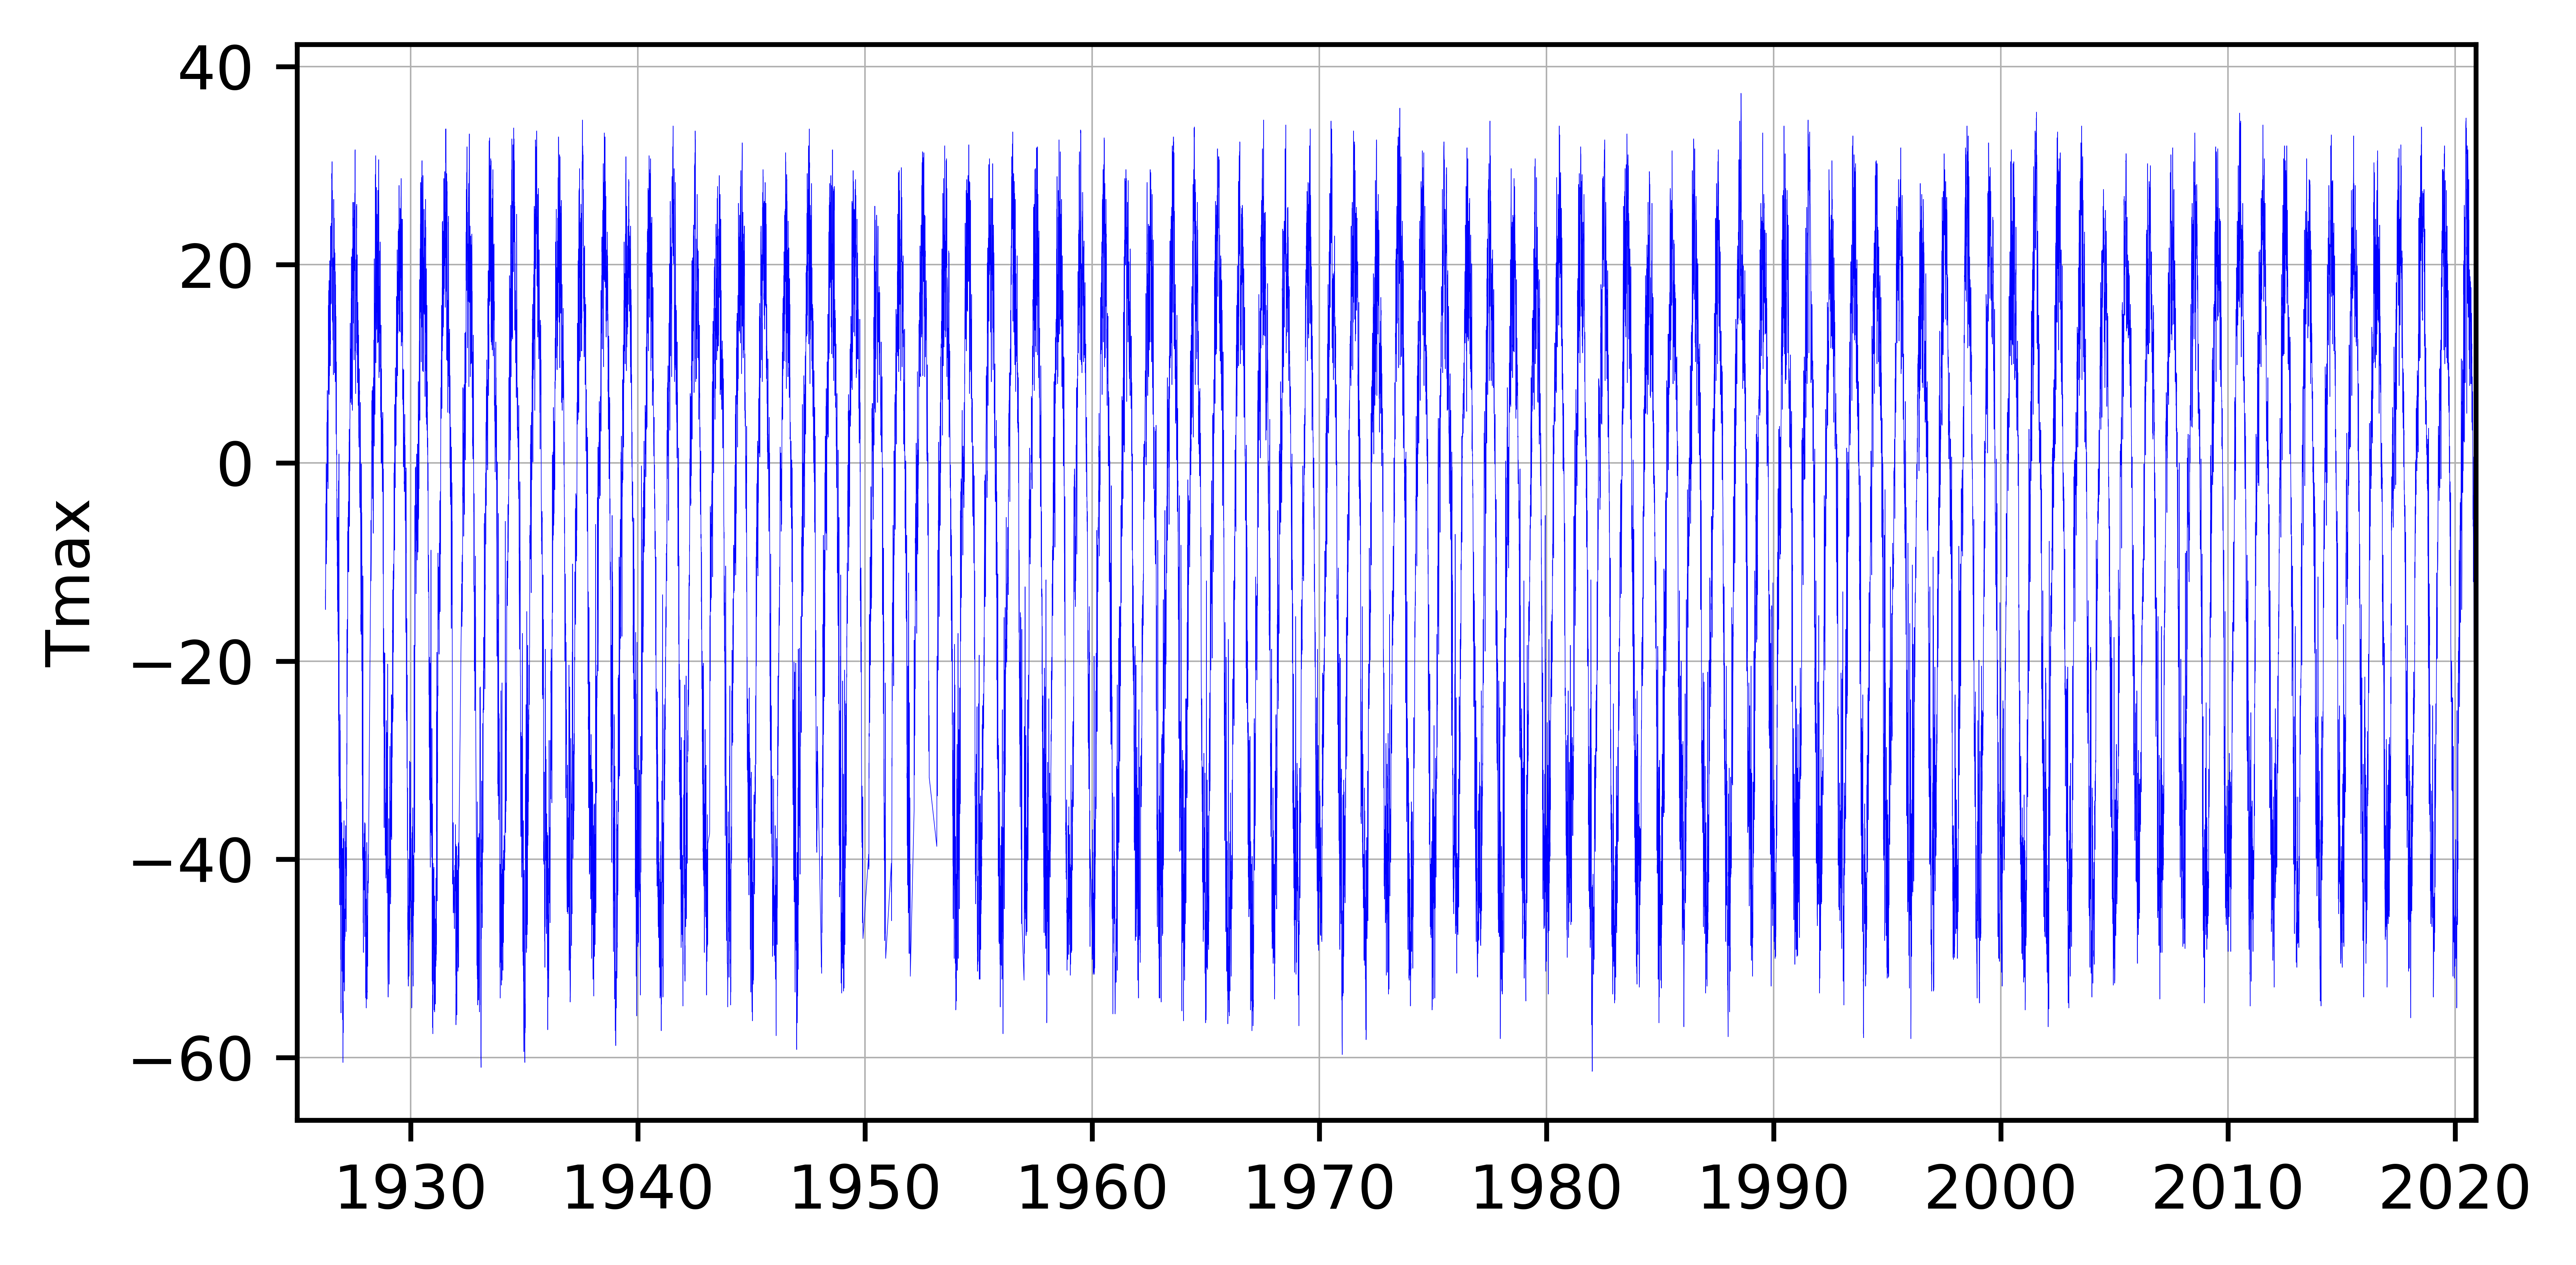

In [3]:
# plot
fig=plt.figure(figsize=(6,3),dpi=1200)
plt.plot(Tmax_dates,Tmax,'b',lw=0.1)
#plt.xlabel("year")
plt.xlim(datetime.strptime("1925-01-01", '%Y-%m-%d')\
        ,datetime.strptime("2020-12-01", '%Y-%m-%d'))
#plt.ylim(10,40)
plt.ylabel("Tmax")
plt.grid(lw=0.25)

plt.tight_layout()
plt.show()
#fig.savefig("Output/heat-waves-Siberia-temperature-timeseries.pdf")

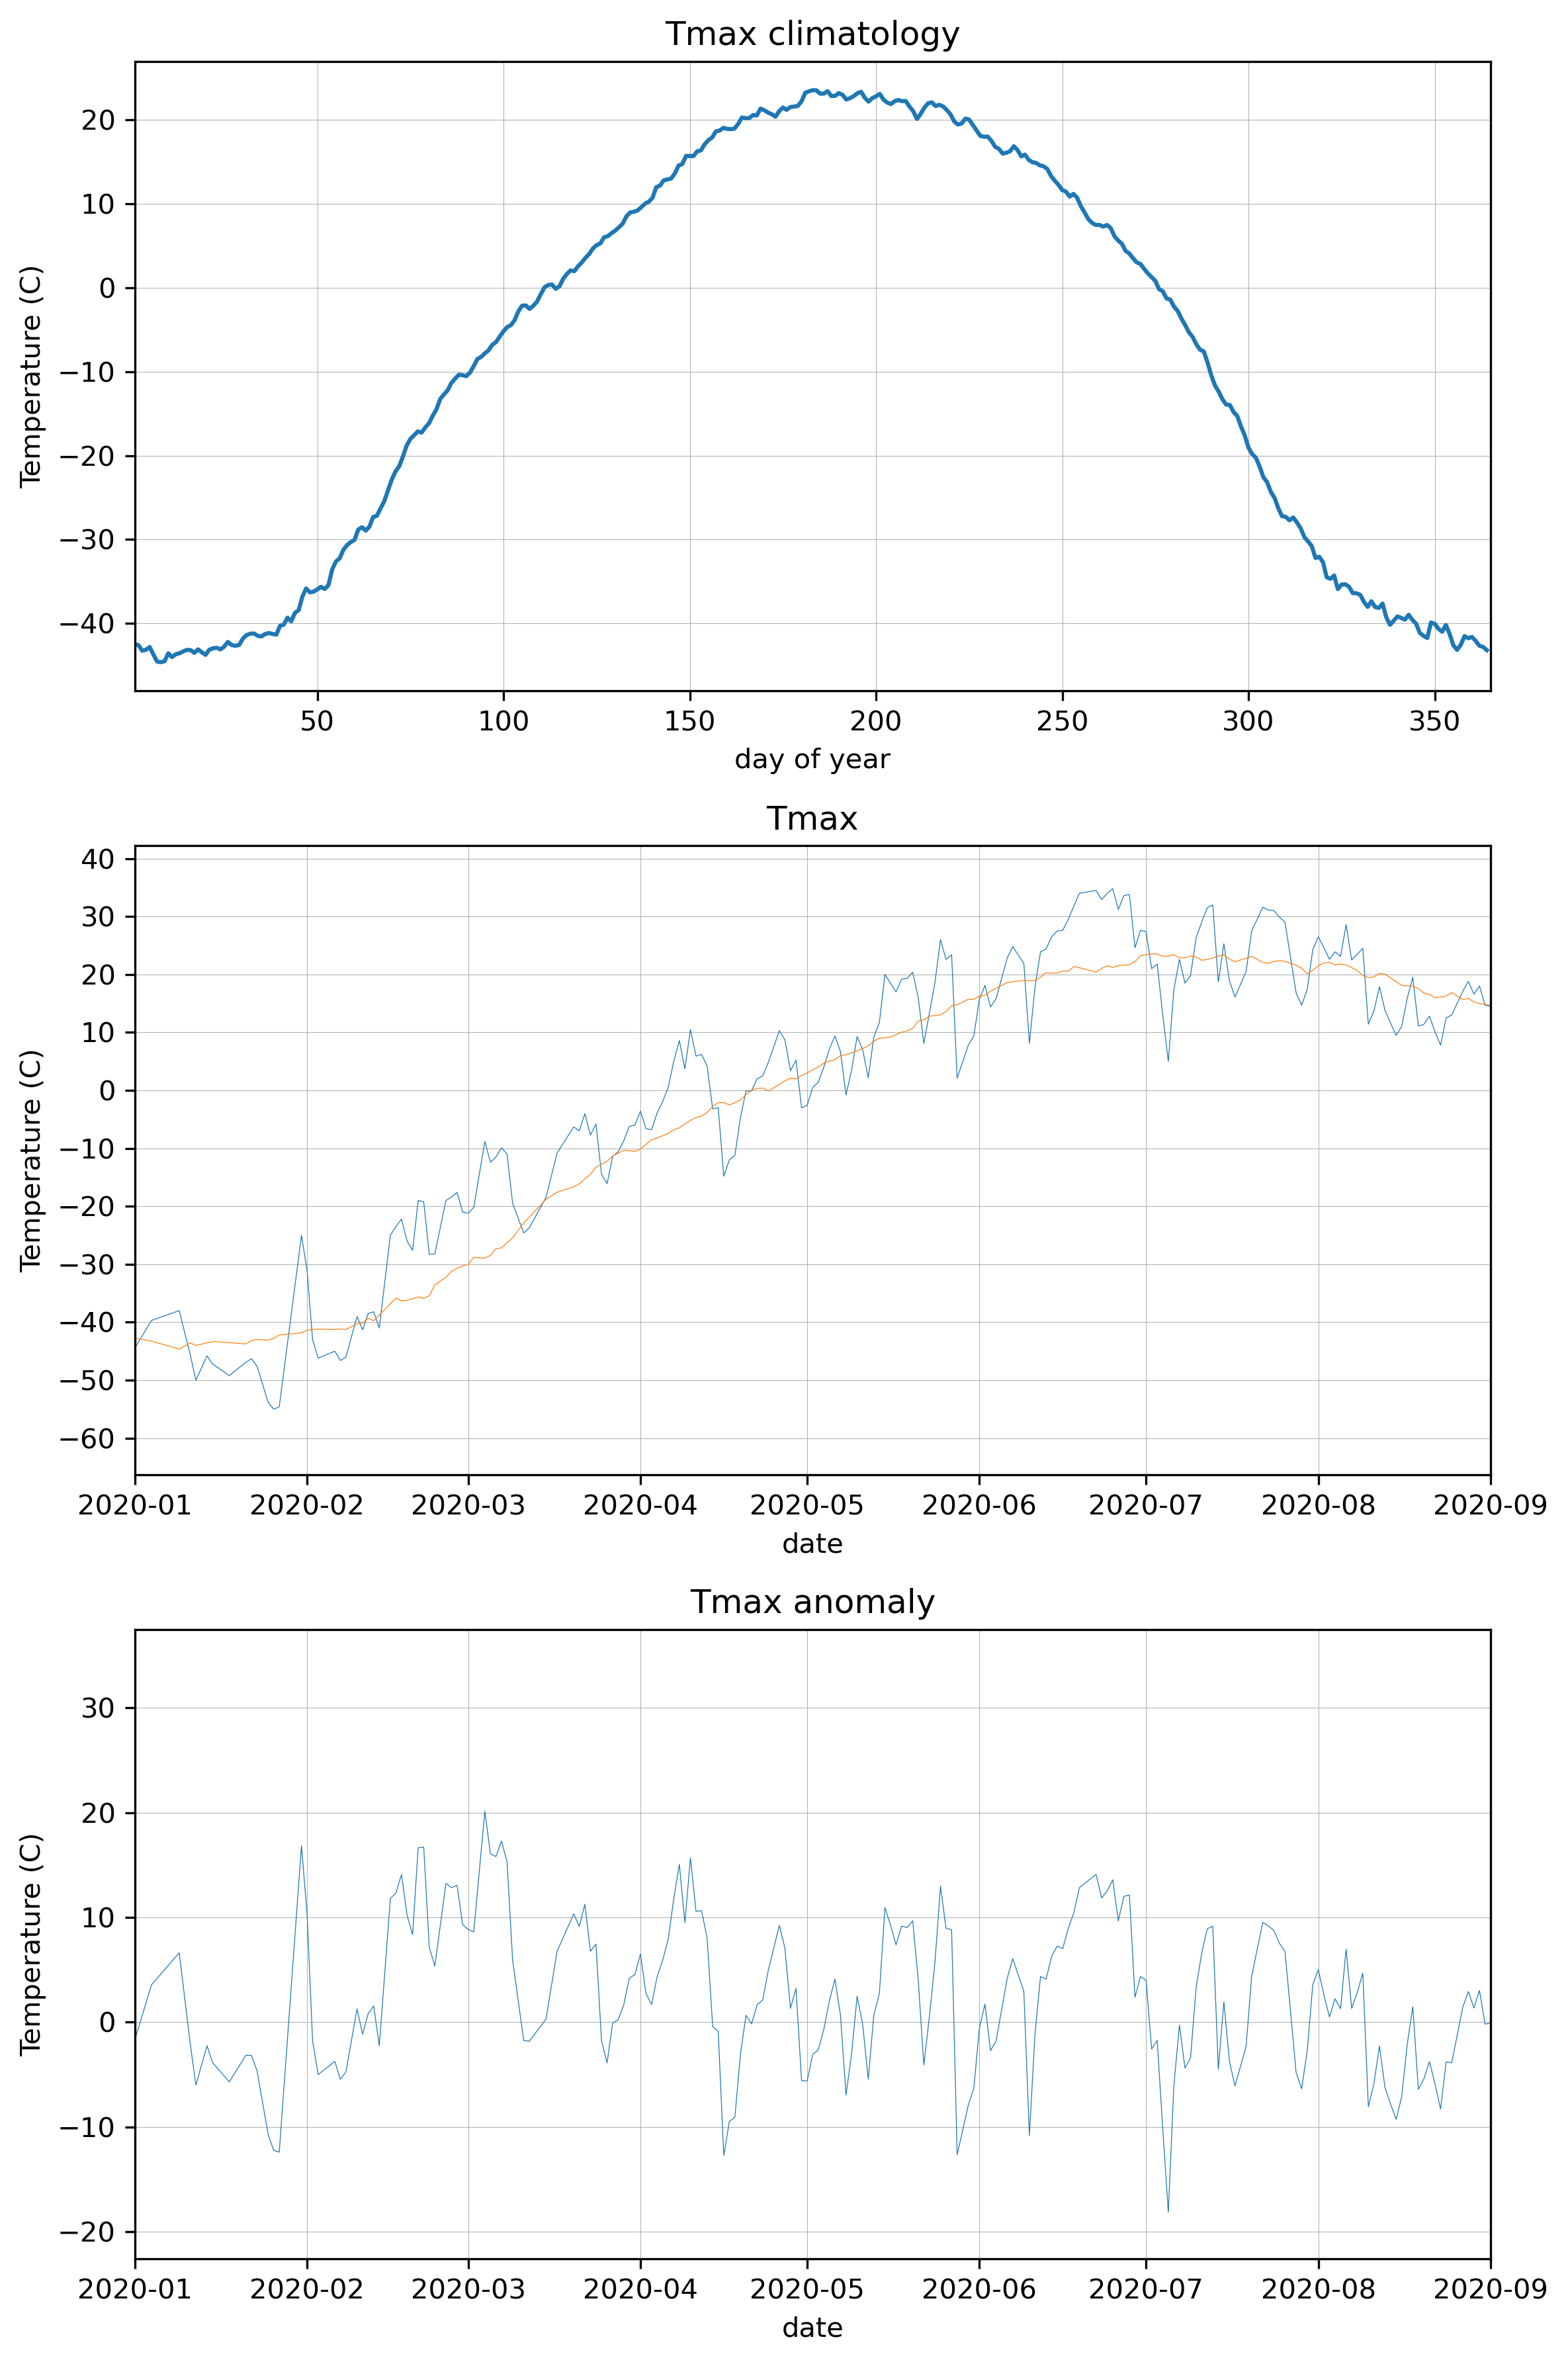

In [4]:
# calculate daily climatology:

Tmax_climatology=np.zeros(365)
for day in np.arange(1,366):
    a=np.asarray(Tmax[Tmax_day_of_year==day],dtype='float')
    Tmax_climatology[day-1]=np.nanmean(a)

Tmax_anomaly=Tmax*np.nan
Tmax_climatology_all_years=Tmax*np.nan
for day in range(len(Tmax)):
    iday=Tmax_day_of_year[day]-1
    Tmax_anomaly[day]=Tmax[day]-Tmax_climatology[iday]
    Tmax_climatology_all_years[day]=Tmax_climatology[iday]

# make sure anomaly has zero climatology:
# Tmax_anomaly_climatology=np.zeros(365)
# for day in np.arange(1,366):
#     a=np.asarray(Tmax_anomaly[Tmax_day_of_year==day],dtype='float')
#     Tmax_anomaly_climatology[day-1]=np.nanmean(a)

# plot daily climatology and anomaly timeseries:
plt.figure(figsize=(8,12),dpi=300)

plt.subplot(3,1,1)
plt.plot(Tmax_climatology)
plt.xlabel("day of year")
plt.ylabel("Temperature (C)")
plt.title("Tmax climatology")
plt.xlim(1,365)
plt.grid(lw=0.25)


plt.subplot(3,1,2)
plt.plot(Tmax_dates,Tmax,lw=0.3)
plt.plot(Tmax_dates,Tmax_climatology_all_years,lw=0.3)
plt.xlabel("date")
plt.ylabel("Temperature (C)")
plt.title("Tmax")
plt.xlim(datetime.strptime("2020-01-01", '%Y-%m-%d')\
        ,datetime.strptime("2020-09-01", '%Y-%m-%d'))
plt.yticks(np.arange(-60,50,10))
plt.grid(lw=0.25)


plt.subplot(3,1,3)
plt.plot(Tmax_dates,Tmax_anomaly,lw=0.3)
plt.xlabel("date")
plt.ylabel("Temperature (C)")
plt.title("Tmax anomaly")
plt.xlim(datetime.strptime("2020-01-01", '%Y-%m-%d')\
        ,datetime.strptime("2020-09-01", '%Y-%m-%d'))
plt.grid(lw=0.25)
plt.tight_layout()